In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir('/Users/syedamishrasaiara/pythonprojects/SQL_Analytics')
DATA = "data/yellow_tripdata_2024-01.parquet"
os.makedirs('charts', exist_ok=True)
print("Ready!")

Ready!


## Advanced SQL — Window Functions & Analytics
This notebook demonstrates advanced SQL techniques including window functions,
rolling averages, percentile ranking, and lag/lead comparisons.

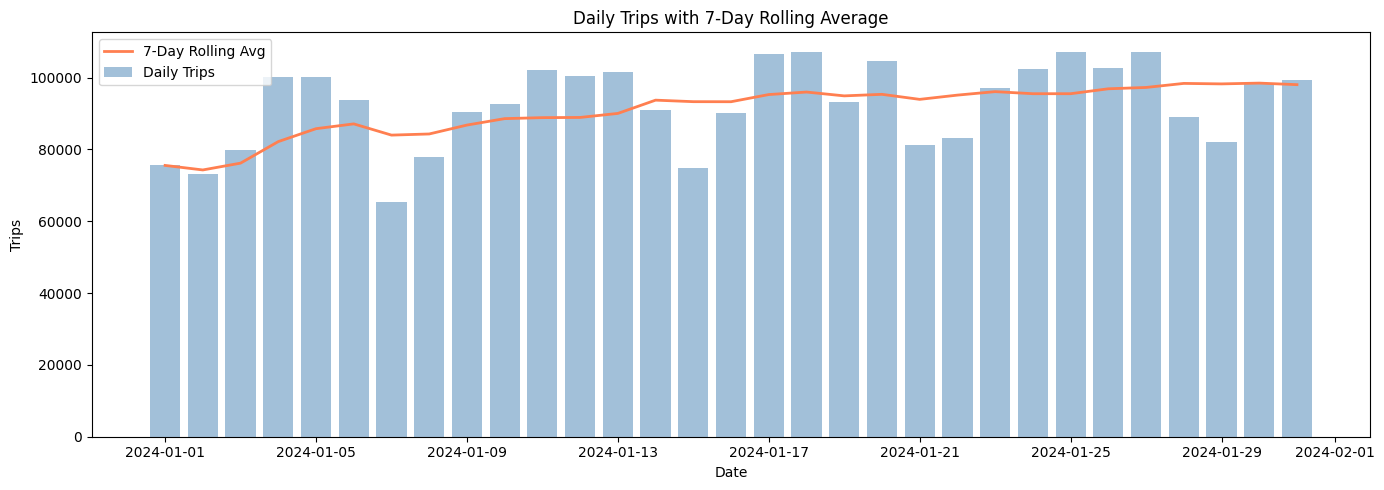

In [6]:
# 7-day rolling average of daily trips
rolling = duckdb.sql(f"""
    WITH daily AS (
        SELECT
            DATE(tpep_pickup_datetime) AS trip_date,
            COUNT(*) AS daily_trips
        FROM '{DATA}'
        WHERE fare_amount > 0
          AND trip_distance > 0
          AND tpep_pickup_datetime >= '2024-01-01'
          AND tpep_pickup_datetime < '2024-02-01'
        GROUP BY trip_date
    )
    SELECT
        trip_date,
        daily_trips,
        ROUND(AVG(daily_trips) OVER (
            ORDER BY trip_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ), 0) AS rolling_7day_avg
    FROM daily
    ORDER BY trip_date
""").df()

plt.figure(figsize=(14, 5))
plt.bar(rolling['trip_date'], rolling['daily_trips'], color='steelblue', alpha=0.5, label='Daily Trips')
plt.plot(rolling['trip_date'], rolling['rolling_7day_avg'], color='coral', linewidth=2, label='7-Day Rolling Avg')
plt.legend()
plt.title('Daily Trips with 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.tight_layout()
plt.savefig('charts/rolling_average.png', dpi=150)
plt.show()

In [3]:
# Day-over-day revenue change (LAG)
lag = duckdb.sql(f"""
    WITH daily_rev AS (
        SELECT
            DATE(tpep_pickup_datetime) AS trip_date,
            ROUND(SUM(total_amount), 2) AS revenue
        FROM '{DATA}'
        WHERE fare_amount > 0 AND trip_distance > 0
        GROUP BY trip_date
    )
    SELECT
        trip_date,
        revenue,
        LAG(revenue) OVER (ORDER BY trip_date) AS prev_day_revenue,
        ROUND(revenue - LAG(revenue) OVER (ORDER BY trip_date), 2) AS day_change,
        ROUND((revenue - LAG(revenue) OVER (ORDER BY trip_date))
              / LAG(revenue) OVER (ORDER BY trip_date) * 100, 1) AS pct_change
    FROM daily_rev
    ORDER BY trip_date
""").df()

lag.head(10)

,trip_date,revenue,prev_day_revenue,day_change,pct_change
0,2002-12-31,10.50,NaN,NaN,NaN
1,2009-01-01,127.69,10.50,117.19,1116.1
2,2023-12-31,224.62,127.69,96.93,75.9
3,2024-01-01,2338847.47,224.62,2338622.85,1041146.3
4,2024-01-02,2256011.47,2338847.47,-82836.00,-3.5
5,2024-01-03,2338629.52,2256011.47,82618.05,3.7
6,2024-01-04,2781199.67,2338629.52,442570.15,18.9
7,2024-01-05,2701994.39,2781199.67,-79205.28,-2.8
8,2024-01-06,2404157.93,2701994.39,-297836.46,-11.0
9,2024-01-07,1872602.09,2404157.93,-531555.84,-22.1


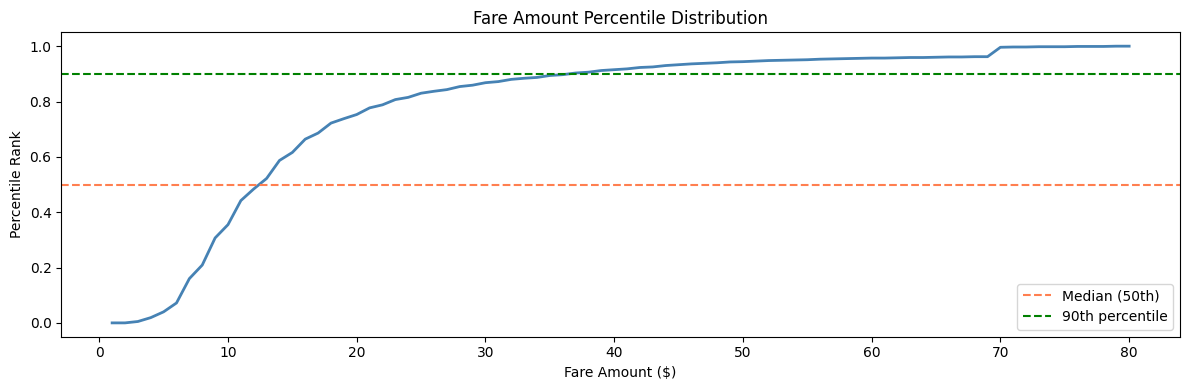

In [5]:
# Percentile ranking of fares (NTILE + PERCENT_RANK)
percentiles = duckdb.sql(f"""
    WITH fare_buckets AS (
        SELECT
            ROUND(fare_amount, 0) AS fare_bucket,
            COUNT(*) AS trips
        FROM '{DATA}'
        WHERE fare_amount BETWEEN 1 AND 80
        GROUP BY ROUND(fare_amount, 0)
    )
    SELECT
        fare_bucket,
        trips,
        ROUND(
            SUM(trips) OVER (ORDER BY fare_bucket) * 1.0 /
            SUM(trips) OVER ()
        , 3) AS percentile_rank
    FROM fare_buckets
    ORDER BY fare_bucket
""").df()

plt.figure(figsize=(12, 4))
plt.plot(percentiles['fare_bucket'], percentiles['percentile_rank'], color='steelblue', linewidth=2)
plt.axhline(0.5, color='coral', linestyle='--', label='Median (50th)')
plt.axhline(0.9, color='green', linestyle='--', label='90th percentile')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Percentile Rank')
plt.title('Fare Amount Percentile Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('charts/fare_percentiles.png', dpi=150)
plt.show()

## Key Techniques Demonstrated

- **ROW/RANGE windows**: The 7-day rolling average reveals a clear upward 
  demand trend across January — starting around 75,000 trips/day in the 
  first week and climbing to ~95,000+ by month end, smoothing out the 
  weekly dips that would otherwise obscure the trend
- **Weekly rhythm visible**: Sharp dips appear every ~7 days (Jan 7, 
  Jan 14, Jan 21, Jan 28) — all Sundays — confirming a strong and 
  consistent day-of-week pattern throughout the month
- **LAG**: Day-over-day revenue change shows real January daily swings 
  of -22% on Sundays and up to +18.9% on Thursdays — the LAG function 
  makes these transitions immediately quantifiable
- **Cumulative SUM window**: Used as a manual percentile rank — the fare 
  distribution curve confirms 50% of trips fall below ~$13 and 90% fall 
  below ~$38, meaning most NYC taxi trips are short and inexpensive
- **Fare distribution insight**: The curve flattens sharply after $38 — 
  the top 10% of fares are spread across a wide $38–$80+ range, driven 
  by airport runs and long-haul trips, with the JFK $70 flat rate 
  visible as a subtle step near $70
- **Data quality lesson**: Corrupt timestamps appeared across multiple 
  notebooks — always apply strict date range filters before any 
  time-series analysis on real-world datasets